In [84]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


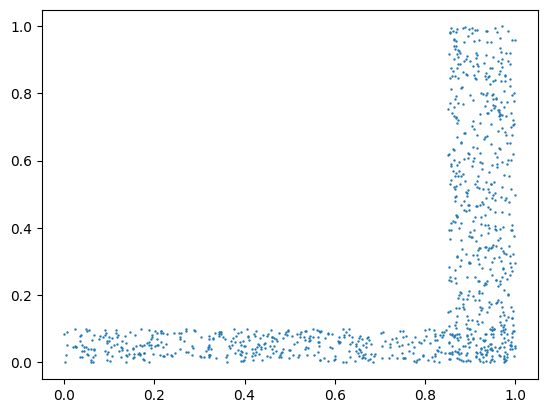

In [249]:
## Utilities.
# Anchor.py

import numpy as np
import matplotlib.pyplot as plt

def make_enrichment_anchors(n_r: int, n_t: int, delta_r: float, delta_t: float, T: float = 1.0) -> np.ndarray:
    ''' Returns: anchors: np.ndarray of shape (n_r + n_t, 2), columns = [r, t]'''
    rng = np.random.default_rng(seed=42)

    # Add points near r=1.
    r_spatial = rng.uniform(1.0 - delta_r, 1.0, size=n_r)
    t_spatial = rng.uniform(0.0, T, size=n_r)
    x_near_surface = np.column_stack([r_spatial, t_spatial])

    # Add points near t=0.
    r_temporal = rng.uniform(0.0, 1.0, n_t)
    t_temporal = rng.uniform(0.0, delta_t * T, n_t)
    x_near_initial_time = np.column_stack([r_temporal, t_temporal])

    return np.vstack([x_near_surface, x_near_initial_time])

anchor = make_enrichment_anchors(500, 500, 0.15, 0.10)    
plt.scatter(anchor[:, 0], anchor[:, 1], s=0.5)

Setting the default backend to "pytorch". You can change it in the ~/.deepxde/config.json file or export the DDE_BACKEND environment variable. Valid options are: tensorflow.compat.v1, tensorflow, pytorch, jax, paddle (all lowercase)


/Users/giorgosvlachonikoleas/Developer/Spheroid_PINN_Project/venv/lib/python3.9/site-packages/skopt/sampler/sobol.py:521: UserWarning: The balance properties of Sobol' points require n to be a power of 2. 0 points have been previously generated, then: n=0+2001=2001. 
  warnings.warn(
/Users/giorgosvlachonikoleas/Developer/Spheroid_PINN_Project/venv/lib/python3.9/site-packages/skopt/sampler/sobol.py:521: UserWarning: The balance properties of Sobol' points require n to be a power of 2. 0 points have been previously generated, then: n=0+401=401. 
  warnings.warn(


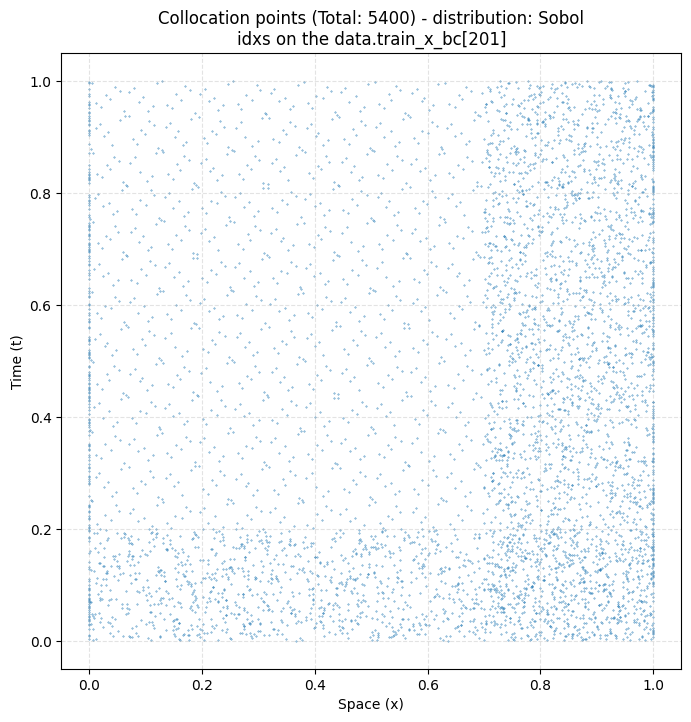

Compiling model...
'compile' took 0.001142 s

Training model...

Step      Train loss                                  Test loss                                   Test metric
0         [4.58e+02, 4.92e+00, 1.09e-01, 2.73e-01]    [4.58e+02, 4.92e+00, 1.09e-01, 2.73e-01]    []  
1         [4.44e+02, 4.80e+00, 1.10e-01, 2.66e-01]    [4.44e+02, 4.80e+00, 1.10e-01, 2.66e-01]    []  

Best model at step 1:
  train loss: 4.49e+02
  test loss: 4.49e+02
  test metric: []

'train' took 3.745586 s

Raw losses at step 0: [4.5816614e+02 4.9206152e+00 1.0941212e-01 2.7274814e-01]
Training model...

Step      Train loss                                  Test loss                                   Test metric
1         [4.44e+02, 4.80e+00, 1.10e-01, 2.66e-01]    [4.44e+02, 4.80e+00, 1.10e-01, 2.66e-01]    []  
100       [3.72e+01, 7.69e-01, 1.27e-01, 3.84e-02]    [3.72e+01, 7.69e-01, 1.27e-01, 3.84e-02]    []  


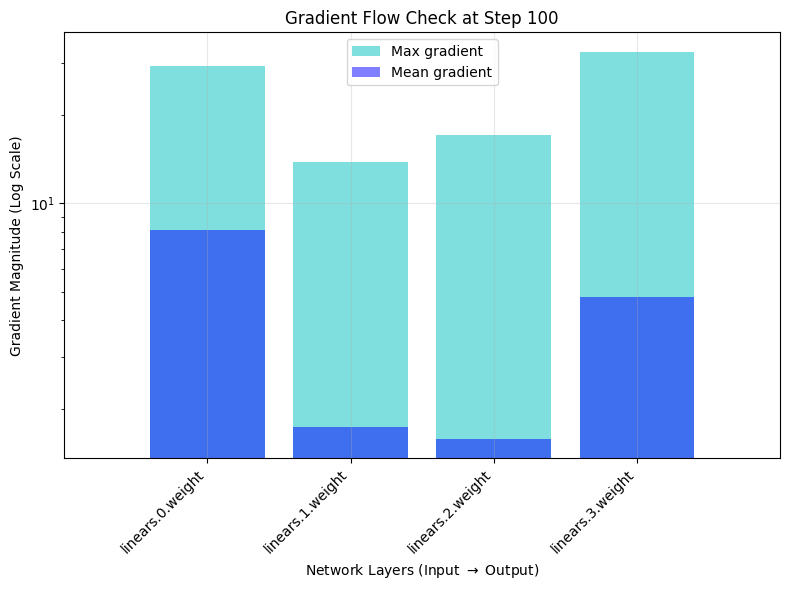

200       [1.04e+01, 3.27e-01, 1.10e-01, 1.32e-02]    [1.04e+01, 3.27e-01, 1.10e-01, 1.32e-02]    []  
300       [4.68e+00, 1.95e-01, 8.91e-02, 6.66e-03]    [4.68e+00, 1.95e-01, 8.91e-02, 6.66e-03]    []  
400       [2.61e+00, 1.34e-01, 7.33e-02, 4.08e-03]    [2.61e+00, 1.34e-01, 7.33e-02, 4.08e-03]    []  
500       [1.65e+00, 1.01e-01, 6.35e-02, 2.80e-03]    [1.65e+00, 1.01e-01, 6.35e-02, 2.80e-03]    []  
600       [1.13e+00, 7.96e-02, 5.76e-02, 2.07e-03]    [1.13e+00, 7.96e-02, 5.76e-02, 2.07e-03]    []  
700       [8.12e-01, 6.51e-02, 5.42e-02, 1.61e-03]    [8.12e-01, 6.51e-02, 5.42e-02, 1.61e-03]    []  
800       [6.10e-01, 5.47e-02, 5.22e-02, 1.30e-03]    [6.10e-01, 5.47e-02, 5.22e-02, 1.30e-03]    []  
900       [4.71e-01, 4.68e-02, 5.08e-02, 1.08e-03]    [4.71e-01, 4.68e-02, 5.08e-02, 1.08e-03]    []  
1000      [3.73e-01, 4.07e-02, 4.97e-02, 9.12e-04]    [3.73e-01, 4.07e-02, 4.97e-02, 9.12e-04]    []  
1001      [3.72e-01, 4.07e-02, 4.97e-02, 9.11e-04]    [3.72e-01, 4.07e-02

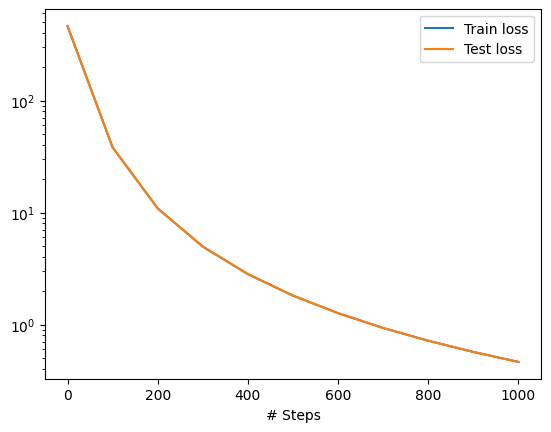

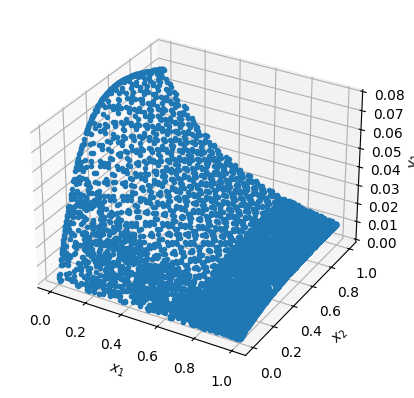

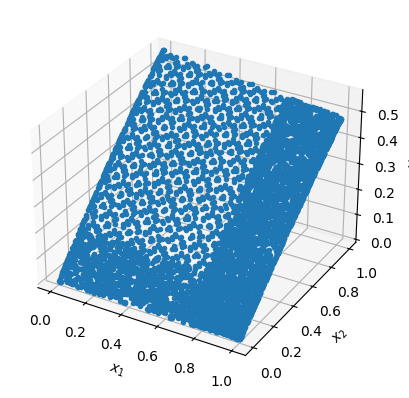

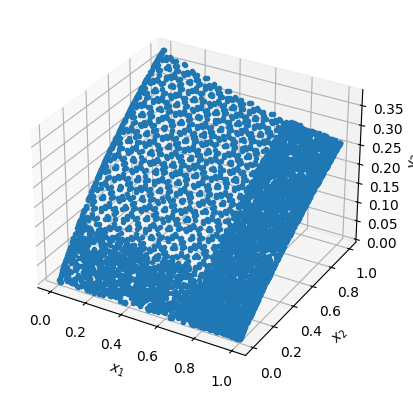

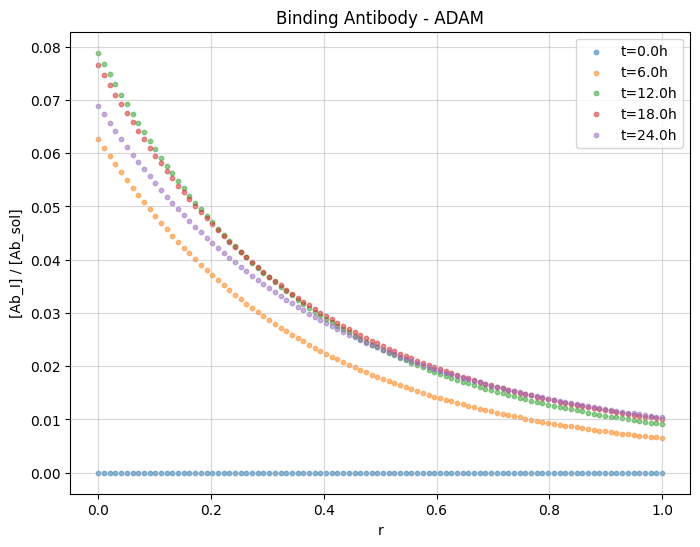

In [280]:
import deepxde as dde
from spheroid_deepxde.utils.context import DimLessModel, Antibody, CharacteristicUnits, PhaseSpecification, phi_antibody, phi_liposomes
from spheroid_deepxde.pdes.antibody import binding_antibody_system_of_pdes, robin_surface_binding_antibody, hard_output_transform, hard_feature_transform
from spheroid_deepxde.utils.boundary_filters import initial_time_filter, center_filter, surface_filter
from spheroid_deepxde.utils.neural_nets import ModifiedPINN
from spheroid_deepxde.utils.plotting import scatter_collocation_points
from spheroid_deepxde.utils.plotting import plot_2d_antibody, plot_2d_liposome
from spheroid_deepxde.utils.callbacks import GradientDiagnosticCallback, AdaptiveLossWeighting


# set pytorch as the default backend.
dde.backend.set_default_backend("pytorch")

### 1. Define problem objects.
transtuzumab = Antibody(D=8.38, Koff=4e-3, Kd=6.76, Kint=1.4e-5, Rt=1060, phi=lambda r: 0.44 * r**3.2 + 0.56)

units = CharacteristicUnits(C0=60, R=200)
uptake_spec = PhaseSpecification('uptake', tau=24*3600, Cext=60, P=2.5e-4)
uptake_dimless = DimLessModel(transtuzumab, units, uptake_spec)


### 2. Spatiotemporal geometry.
## BINDING ANTIBODIES...
hours = 24
t_end = hours / 24 
geometry = dde.geometry.Interval(0, 1) # 1D spatial domain (normalized radius)
timedomain = dde.geometry.TimeDomain(0, t_end) # temporal domain (normalized time)
spacetime = dde.geometry.GeometryXTime(geometry, timedomain) # spatiotemporal domain



### 3. Define boundary and initial conditions.
# ICs
ic_interstitial = dde.icbc.IC(
    geom=spacetime,
    func=lambda x: 0.0,
    on_initial=initial_time_filter,
    component=0
)
ic_bound = dde.icbc.IC(
    geom=spacetime,
    func=lambda x: 0.0,
    on_initial=initial_time_filter,
    component=1
)
ic_internalized = dde.icbc.IC(
    geom=spacetime,
    func=lambda x: 0.0,
    on_initial=initial_time_filter,
    component=2
)

# BCs.
center_neumann = dde.icbc.NeumannBC(
    geom=spacetime,
    func=lambda x: 0.0,
    on_boundary=center_filter,
    component=0
)
surface_robin = dde.icbc.OperatorBC(
    geom=spacetime,
    func=robin_surface_binding_antibody,
    on_boundary=surface_filter
)
######################################################################################################################################################

bc_surface_antibody = dde.icbc.OperatorBC(
    geom=spacetime,
    func=robin_surface_binding_antibody,
    on_boundary=surface_filter
)
ic_bcs_antibody = [surface_robin]
loss_weights = [1e-3, 1e-3, 1.0, 1.0]

gradient_check = GradientDiagnosticCallback()
adaptive_loss_weighting = AdaptiveLossWeighting(
    update_every=1000,
    momentum=0.9,
    base_weights=loss_weights
)

dist = {"a": 'LHS', 'b': 'Halton', 'c': 'Hammersley', 'd': 'Sobol'}
extra_points = make_enrichment_anchors(n_r=2000, n_t=1000, delta_r=0.30, delta_t=0.2, T=t_end)

data = dde.data.TimePDE(
    geometryxtime=spacetime,
    pde=binding_antibody_system_of_pdes,
    ic_bcs=ic_bcs_antibody,
    num_domain=2000,
    num_boundary=400,
    num_initial=0,
    train_distribution=dist['d'],
    anchors=extra_points
)
scatter_collocation_points(data)

layer_size = [2] + [64] * 3 + [3]
fnn_net = dde.nn.FNN(layer_size, "tanh", "Glorot normal")
mod_net = ModifiedPINN(
    in_dim=2, 
    out_dim=3, 
    hidden_dim=64, 
    num_layers=3
)


# fnn_net.apply_feature_transform(hard_feature_transform) # Enforce symmetry at r=0 and zero initial condition at t=0 through input transformation
fnn_net.apply_output_transform(hard_output_transform) # Scale output by time to enforce zero initial condition at t=0

model = dde.Model(data, fnn_net)

model.compile(
    optimizer="adam", 
    lr=1e-4, 
    loss_weights=loss_weights
)
##
# --- Loss magnitude diagnostic ---
import torch

# sample a batch of points
sample_pts = data.train_x_all
sample_pts_tensor = torch.tensor(sample_pts, dtype=torch.float32, requires_grad=True)

# get raw losses before any training
test_loss = model.sess if hasattr(model, 'sess') else None

# simpler: just run one step and print
losshistory_test, _ = model.train(iterations=1, display_every=1)
print("Raw losses at step 0:", losshistory_test.loss_train[0])
##
adam_losshistory, adam_train_state = model.train(
    iterations=1000, 
    display_every=100, 
    callbacks=[gradient_check]
)

dde.saveplot(
    adam_losshistory, 
    adam_train_state, 
    issave=True, 
    isplot=True
)
adam_model = model

plot_2d_antibody(adam_model, time_list=[0.0, t_end/4, 2*t_end/4, 3*t_end/4, t_end], C_scale=1, r_scale=1, t_scale=hours, save_path=None, 
                 lambda_phi=phi_antibody, 
                 title='Binding Antibody - ADAM')

# # Phase 2: Precision Fine-Tuning
# model.compile(
#     optimizer='L-BFGS', 
#     loss_weights=loss_weights_binding_antibody
# )

# lbfgs_losshistory, lbfgs_train_state = model.train()

# dde.saveplot(
#     lbfgs_losshistory, 
#     lbfgs_train_state, 
#     issave=True, 
#     isplot=True)

# lbfgs_model = model

# plot_2d_antibody(lbfgs_model, time_list=[0.0, 1/16, 4/16, 8/16, 1.0], C_scale=1, r_scale=1, t_scale=24, save_path=None, 
#                  lambda_phi=phi_antibody, 
#                  title='Binding Antibody - L-BFGS')

Compiling model...
'compile' took 0.000602 s



/Users/giorgosvlachonikoleas/Developer/Spheroid_PINN_Project/venv/lib/python3.9/site-packages/skopt/sampler/sobol.py:521: UserWarning: The balance properties of Sobol' points require n to be a power of 2. 0 points have been previously generated, then: n=0+3001=3001. 
  warnings.warn(
/Users/giorgosvlachonikoleas/Developer/Spheroid_PINN_Project/venv/lib/python3.9/site-packages/skopt/sampler/sobol.py:521: UserWarning: The balance properties of Sobol' points require n to be a power of 2. 0 points have been previously generated, then: n=0+301=301. 
  warnings.warn(
/Users/giorgosvlachonikoleas/Developer/Spheroid_PINN_Project/venv/lib/python3.9/site-packages/skopt/sampler/sobol.py:521: UserWarning: The balance properties of Sobol' points require n to be a power of 2. 0 points have been previously generated, then: n=0+201=201. 
  warnings.warn(


Training model...

Step      Train loss                                                      Test loss                                                       Test metric
0         [2.94e-01, 2.56e-01, 2.27e-05, 9.82e-01, 8.14e+00, 7.32e-02]    [2.94e-01, 2.56e-01, 2.27e-05, 9.82e-01, 8.14e+00, 7.32e-02]    []  
100       [2.87e-01, 2.50e-01, 2.30e-05, 9.83e-01, 7.81e+00, 7.02e-02]    [2.87e-01, 2.50e-01, 2.30e-05, 9.83e-01, 7.81e+00, 7.02e-02]    []  


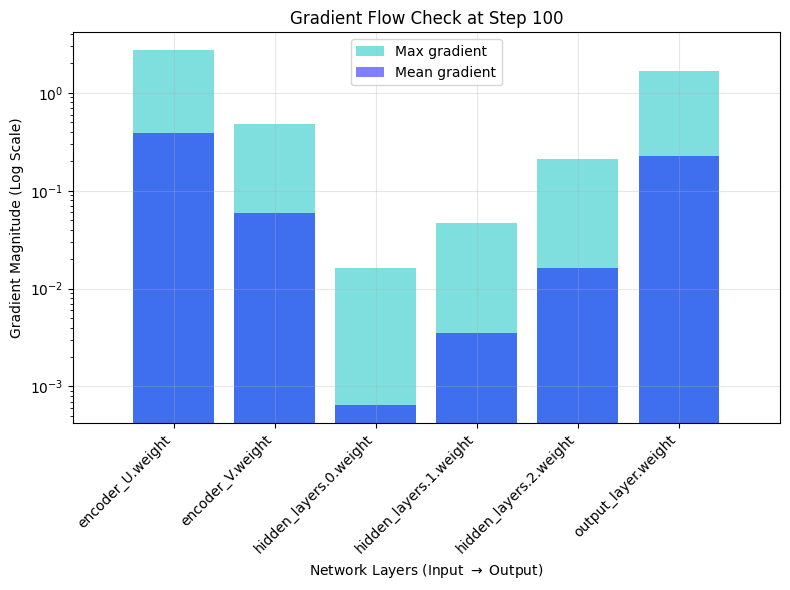

200       [2.81e-01, 2.43e-01, 2.35e-05, 9.85e-01, 7.48e+00, 6.75e-02]    [2.81e-01, 2.43e-01, 2.35e-05, 9.85e-01, 7.48e+00, 6.75e-02]    []  
300       [2.75e-01, 2.37e-01, 2.42e-05, 9.86e-01, 7.15e+00, 6.49e-02]    [2.75e-01, 2.37e-01, 2.42e-05, 9.86e-01, 7.15e+00, 6.49e-02]    []  
400       [2.68e-01, 2.31e-01, 2.51e-05, 9.87e-01, 6.82e+00, 6.26e-02]    [2.68e-01, 2.31e-01, 2.51e-05, 9.87e-01, 6.82e+00, 6.26e-02]    []  
500       [2.62e-01, 2.25e-01, 2.62e-05, 9.88e-01, 6.49e+00, 6.03e-02]    [2.62e-01, 2.25e-01, 2.62e-05, 9.88e-01, 6.49e+00, 6.03e-02]    []  
600       [2.57e-01, 2.20e-01, 2.75e-05, 9.89e-01, 6.17e+00, 5.79e-02]    [2.57e-01, 2.20e-01, 2.75e-05, 9.89e-01, 6.17e+00, 5.79e-02]    []  
700       [2.51e-01, 2.14e-01, 2.91e-05, 9.89e-01, 5.85e+00, 5.55e-02]    [2.51e-01, 2.14e-01, 2.91e-05, 9.89e-01, 5.85e+00, 5.55e-02]    []  
800       [2.46e-01, 2.09e-01, 3.08e-05, 9.90e-01, 5.53e+00, 5.31e-02]    [2.46e-01, 2.09e-01, 3.08e-05, 9.90e-01, 5.53e+00, 5.31e-02]    []  

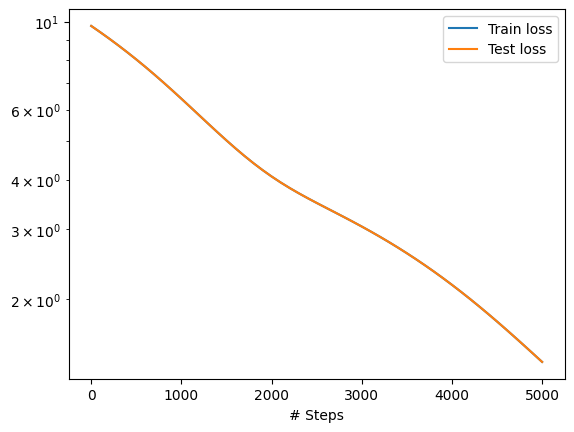

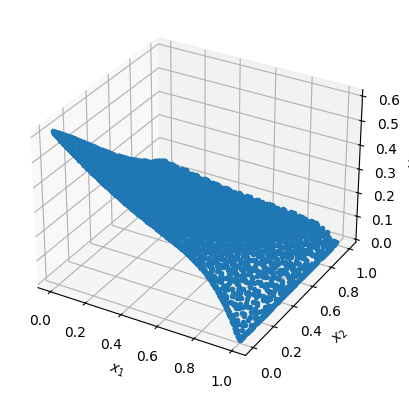

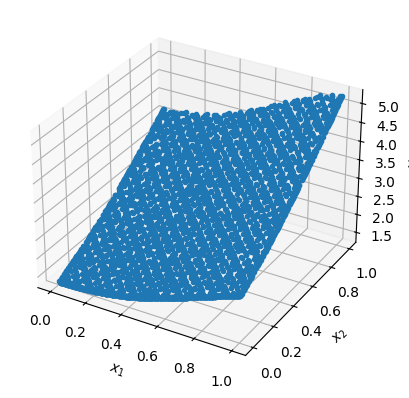

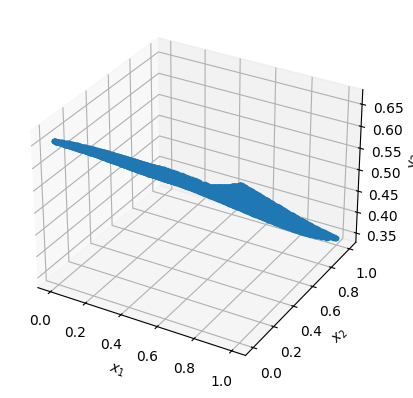

model after training


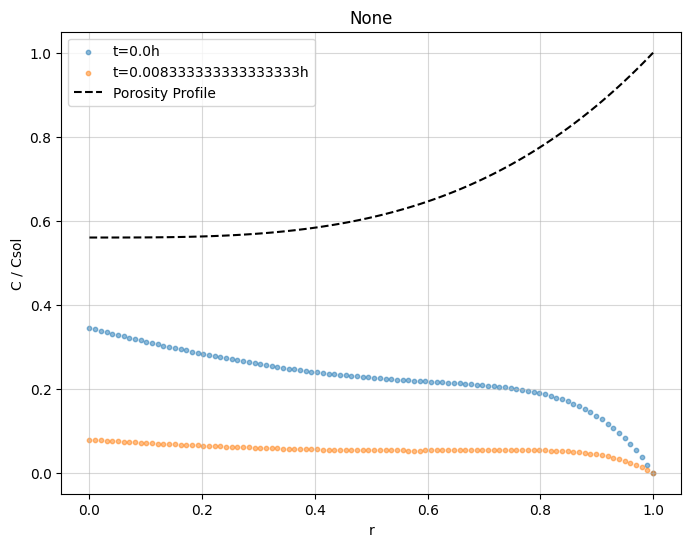

In [ ]:
### FISHING.
import torch
import torch.nn.functional as F
import numpy as np
from spheroid_deepxde.pdes.antibody import binding_antibody_system_of_pdes_fishing, hard_constraint_fishing_surface
from spheroid_deepxde.utils.plotting import plot_2d_antibody

def func_ic_y0(x):
    x_end = np.copy(x)
    x_end[:, 1:2] = 1.0
    return adam_model.predict(x_end)[:, 0:1]

def func_ic_y1(x):
    x_end = np.copy(x)
    x_end[:, 1:2] = 1.0
    return adam_model.predict(x_end)[:, 1:2]

def func_ic_y2(x):
    x_end = np.copy(x)
    x_end[:, 1:2] = 1.0
    return adam_model.predict(x_end)[:, 2:3]

ic_0 = dde.icbc.IC(
    geom=spacetime,
    func= func_ic_y0,
    on_initial=initial_time_filter,
    component=0
)
ic_1 = dde.icbc.IC(
    geom=spacetime,
    func= func_ic_y1,
    on_initial=initial_time_filter,
    component=1
)
ic_2 = dde.icbc.IC(
    geom=spacetime,
    func= func_ic_y2,
    on_initial=initial_time_filter,
    component=2
)
bc_surface = dde.icbc.DirichletBC(
    geom=spacetime,
    func=lambda x: 0.0,
    on_boundary=surface_filter
)
icbcs = [ic_0, ic_1, ic_2]
loss_weights=[1.0, 1.0, 1.0, 10.0, 10.0, 10.0]

data = dde.data.TimePDE(
    geometryxtime=spacetime,
    pde=binding_antibody_system_of_pdes_fishing,
    ic_bcs=icbcs,
    num_domain=3000,
    num_boundary=300,
    num_initial=200,
    train_distribution=dist['d']
)

fishing_net = ModifiedPINN(in_dim=2, out_dim=3, hidden_dim=64, num_layers=3)

fishing_net.load_state_dict(torch.load('spheroid_deepxde/results/antibodies/uptake_weights.pth'))
fishing_net.apply_feature_transform(hard_constraint_center_boundary_transform_antibody)
fishing_net.apply_output_transform(hard_constraint_fishing_surface)

fishing_model = dde.Model(data, fishing_net)

fishing_model.compile(
    optimizer='adam',
    lr=1e-5,
    loss_weights=loss_weights
)

fishing_history, fishing_state = fishing_model.train(
    iterations=5000,
    display_every=100,
    callbacks=[gradient_check]
)
dde.saveplot(
    fishing_history, 
    fishing_state, 
    issave=True, 
    isplot=True
)
print('model after training')
plot_2d_antibody(fishing_model, [0, 1], t_scale=0.5/60, lambda_phi=phi_antibody, C_scale=1, r_scale=1)

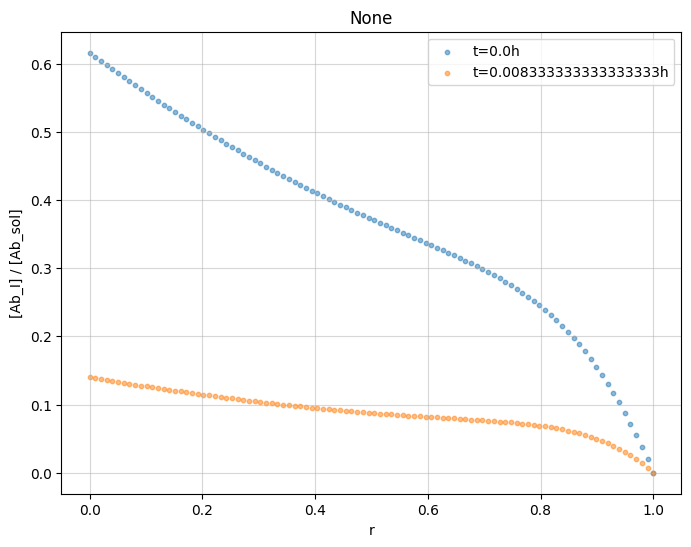

In [181]:
from spheroid_deepxde.utils.plotting import plot_2d_antibody
plot_2d_antibody(fishing_model, [0, 1], t_scale=0.5/60, C_scale=1, r_scale=1)

In [ ]:
import numpy as np

